In [1]:
import testing
from importlib import reload
reload(testing)
from testing import *

In [2]:
rc = {
    "font.family":        "serif",
    "font.size":          12,
    # "axes.labelsize":     12,
    # "axes.titlesize":     13,
    # "xtick.labelsize":    10,
    # "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "text.usetex":        True,
    "figure.dpi":         150,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
}
plt.rcParams.update(rc)

In [3]:
tests: list[Test] = []
for name in Test.measured_folders:
    print(name)
    tests.append(Test(name))

T8_Open_Lab_3\10_150
T8_Open_Lab_3\10_400
T8_Open_Lab_3\5_400
T8_Open_Lab_3\10_100
T8_Open_Lab_2\10_220
T8_Open_Lab_2\15_100
T8_Open_Lab_3\15_150
T8_Open_Lab_3\15_400
T8_Open_Lab_3\15_220
T8_Open_Lab_3\5_150
T8_Open_Lab_2\5_220
T8_Open_Lab_3\5_100


In [4]:
for test in tests:
    print(test.file_prefix)
    test.animate_images("mp4")
    for mode in (1, 2):
        fig, ax = test.show_vel_field(mode)
        fig.tight_layout()
        fig.savefig(fig_path / f"Velocity_Field_{mode}" / f"{test.file_prefix}.png")
        plt.close()

T8_Open_Lab_3_10_150
T8_Open_Lab_3_10_400
T8_Open_Lab_3_5_400
T8_Open_Lab_3_10_100
T8_Open_Lab_2_10_220
T8_Open_Lab_2_15_100
T8_Open_Lab_3_15_150
T8_Open_Lab_3_15_400
T8_Open_Lab_3_15_220
T8_Open_Lab_3_5_150
T8_Open_Lab_2_5_220
T8_Open_Lab_3_5_100


In [5]:
df = pd.DataFrame.from_records([test.to_dict() for test in tests])
df.sort_values("Re", inplace=True)

df["Outlier"] = False
df.loc[(df["D_nominal_mm"] == 5) & (df["grit"] == 100), "Outlier"] = True

z_95 = norm.interval(0.95, loc=0, scale=1)[1]
print(f"{z_95 = :.2f}")
# t_95 = t.interval(0.95, df=n-1, loc=0, scale=1)[1]
df["C_d_CI"] = z_95 * df["C_d_std"]
df["Re_CI"] = z_95 * df["Re_std"]

z_95 = 1.96


In [6]:
df[['D_nominal_mm', 'D', 'grit', 'rel_roughness', 'U_inf', 'Re', 'Re_CI', 'C_d', 'C_d_CI']].to_latex("summary_table.tex", index=False)

In [7]:
print("Median R^2: ", df["r_squared"].median())
print("Min R^2: ", df["r_squared"].min())
print(f"Reynolds range: {df['Re'].min():.0f} - {df['Re'].max():.0f}")
print(f"Reynolds range: {df['U_inf'].min():.2f} - {df['U_inf'].max():.2f}")

for D_nom, cur_df in df.groupby("D_nominal_mm"):
    print(f"{D_nom} {cur_df['D'].min():.2f} {cur_df['D'].max():.2f}")
    print(f"{D_nom} {D_nom-cur_df['D'].min():.2f} {cur_df['D'].max()-D_nom:.2f}")
    print(f"{D_nom} {cur_df['U_inf'].min():.2f} {cur_df['U_inf'].max():.2f}")
    print()

Median R^2:  0.8397642689258504
Min R^2:  0.6343845319497631
Reynolds range: 1662 - 5518
Reynolds range: 1.43 - 2.17
5 5.21 6.64
5 -0.21 1.64
5 1.82 2.03

10 10.00 10.89
10 -0.00 0.89
10 1.89 2.17

15 15.81 16.44
15 -0.81 1.44
15 1.43 1.96



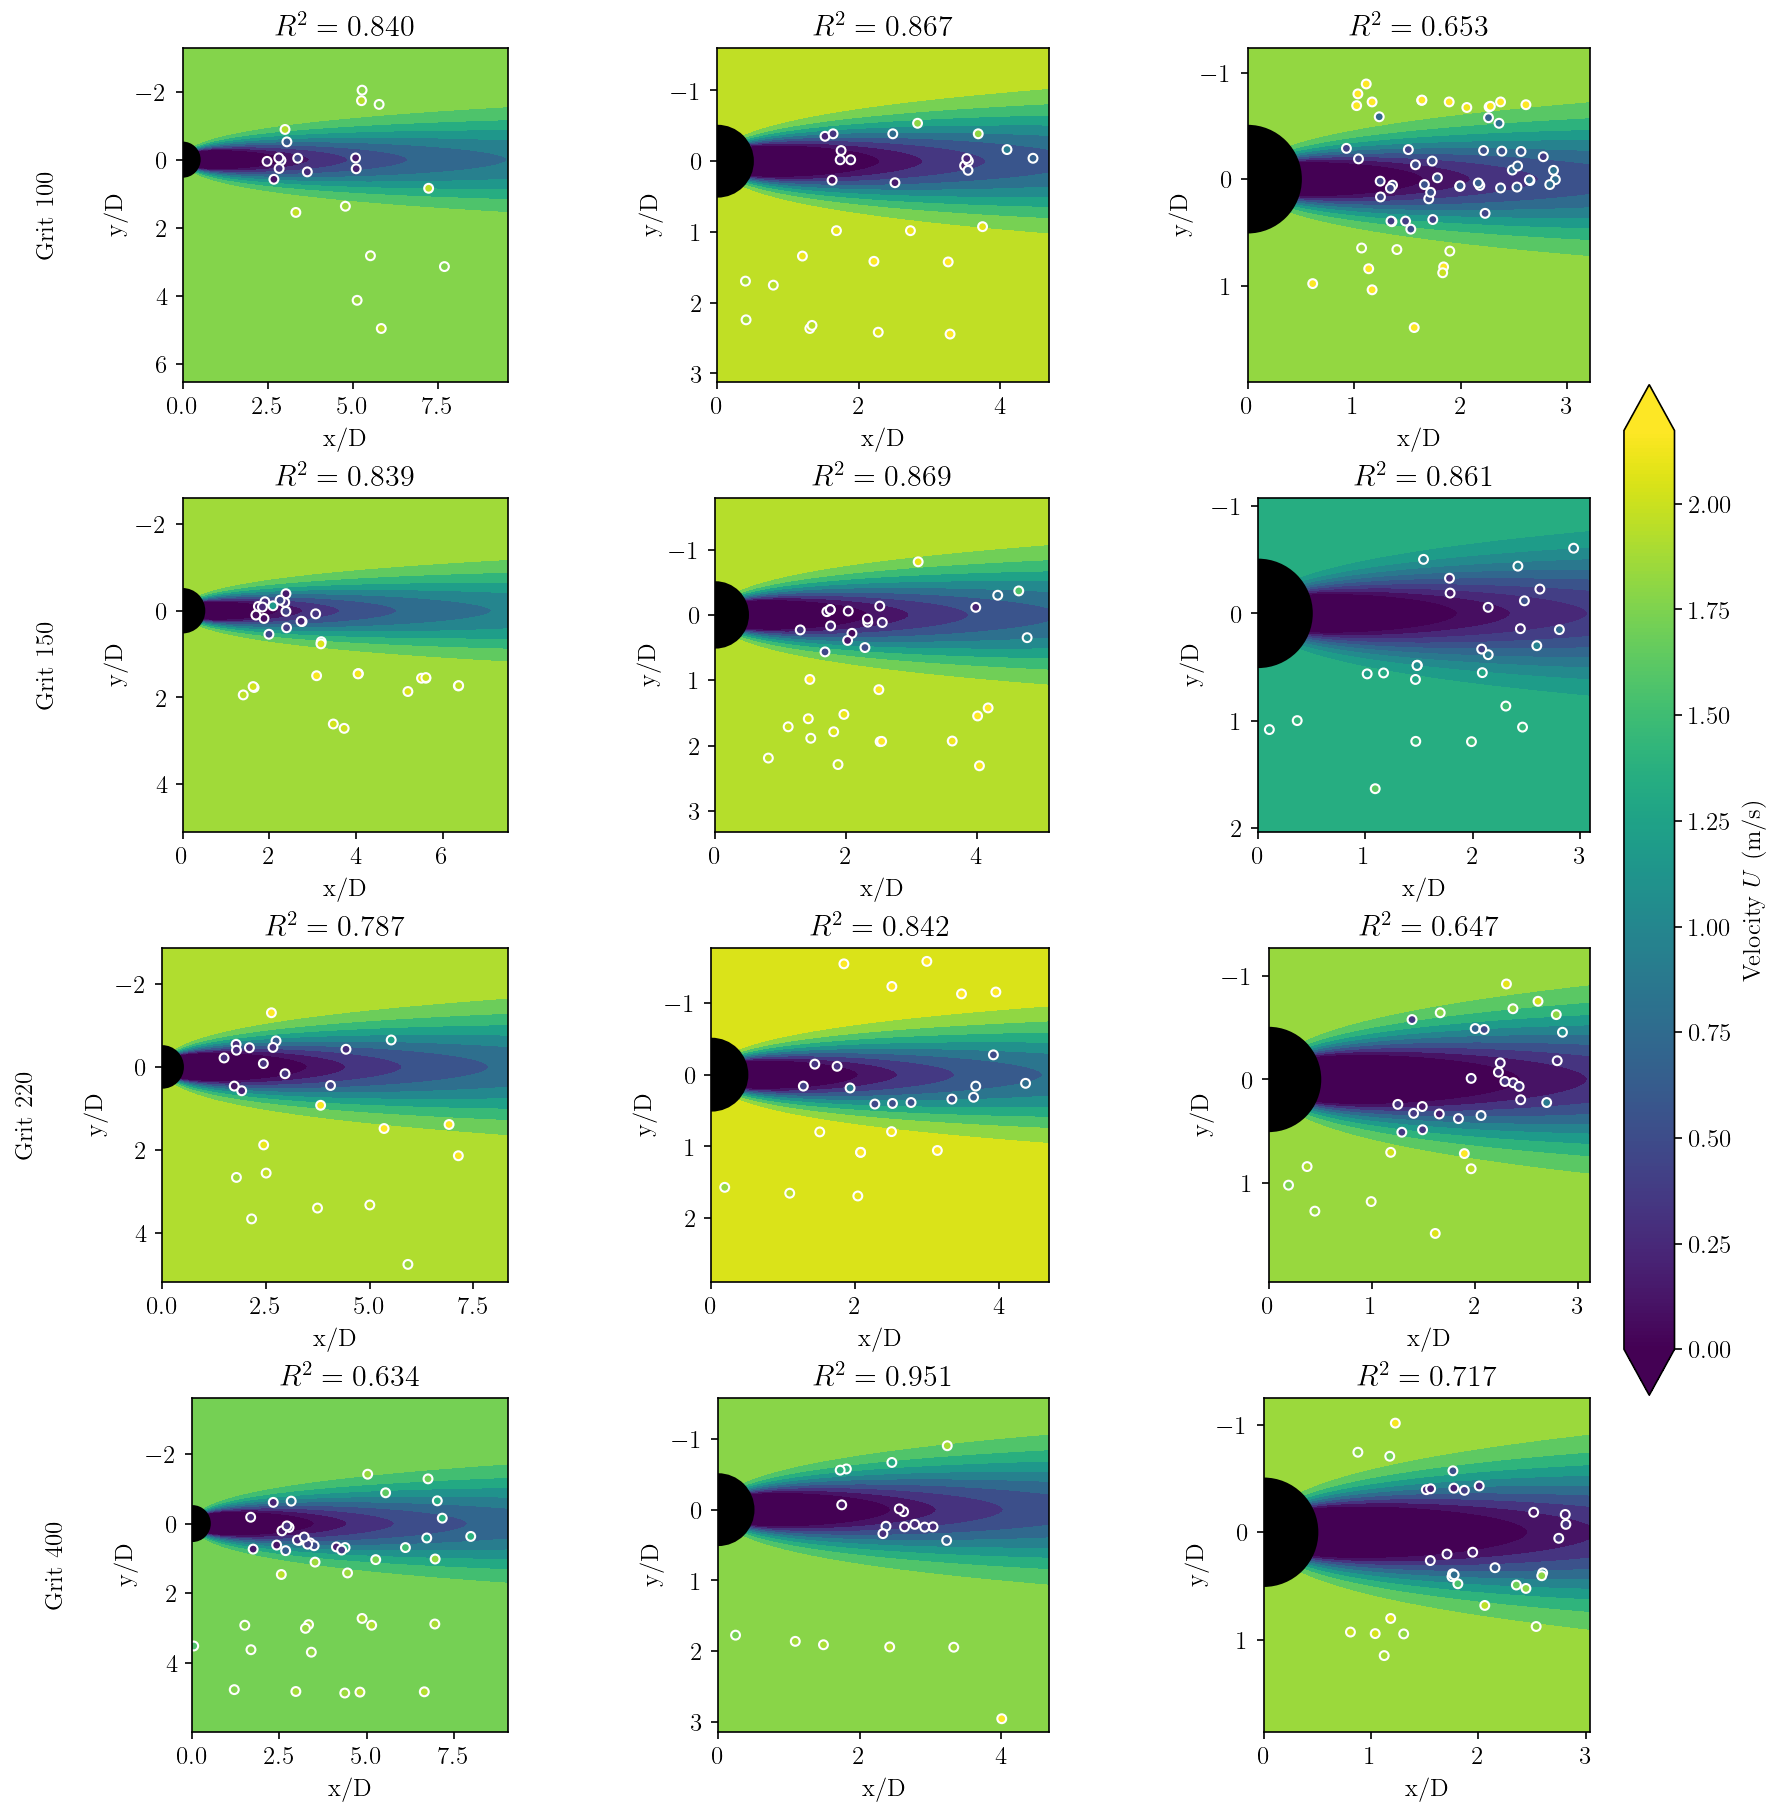

In [8]:
def plot_vel_field_grid(tests: list, figsize=(12, 12)):
    test_map = {(t.grit, t.nominal_diameter_mm): t for t in tests}
    grits     = sorted(set(t.grit for t in tests))
    diameters = sorted(set(t.nominal_diameter_mm for t in tests))
    n_row, n_col = len(grits), len(diameters)

    shared_norm = colors.Normalize(vmin=0.0, vmax=df["U_inf"].max(), clip=True)
    shared_cmap = cm.viridis

    fig, axes = plt.subplots(n_row, n_col, figsize=figsize, constrained_layout=True)

    for col, diam in enumerate(diameters):
        axes[0, col].set_title(f"Nominal $D = {diam}$ mm", fontsize=12, fontweight="bold")
    for row, grit in enumerate(grits):
        axes[row, 0].annotate(
            f"Grit {grit}",
            xy=(0, 0.5), xycoords="axes fraction",
            xytext=(-60, 0), textcoords="offset points",
            ha="right", va="center",
            fontsize=12, fontweight="bold", rotation=90,
        )

    for row, grit in enumerate(grits):
        for col, diam in enumerate(diameters):
            ax = axes[row, col]
            test = test_map.get((grit, diam))

            if test is None:
                ax.set_visible(False)
                continue

            test.show_vel_field(model_num=1, nx=200, ny=200, legend=False, colorbar=False, ax=ax, norm=shared_norm, cmap=shared_cmap)

    mappable = cm.ScalarMappable(norm=shared_norm, cmap=shared_cmap)
    mappable.set_array([])

    fig.colorbar(
        mappable,
        ax=axes.ravel().tolist(), # attaches to the whole grid
        label="Velocity $U$ (m/s)",
        extend="both",
        shrink=0.6,
        pad=0.02,
    )
    # plt.subplots_adjust(hspace=0.2)
    # fig.tight_layout()

    fig.savefig(fig_path / "vel_field_grid.png")

    return fig, axes

plot_vel_field_grid(tests)
pass

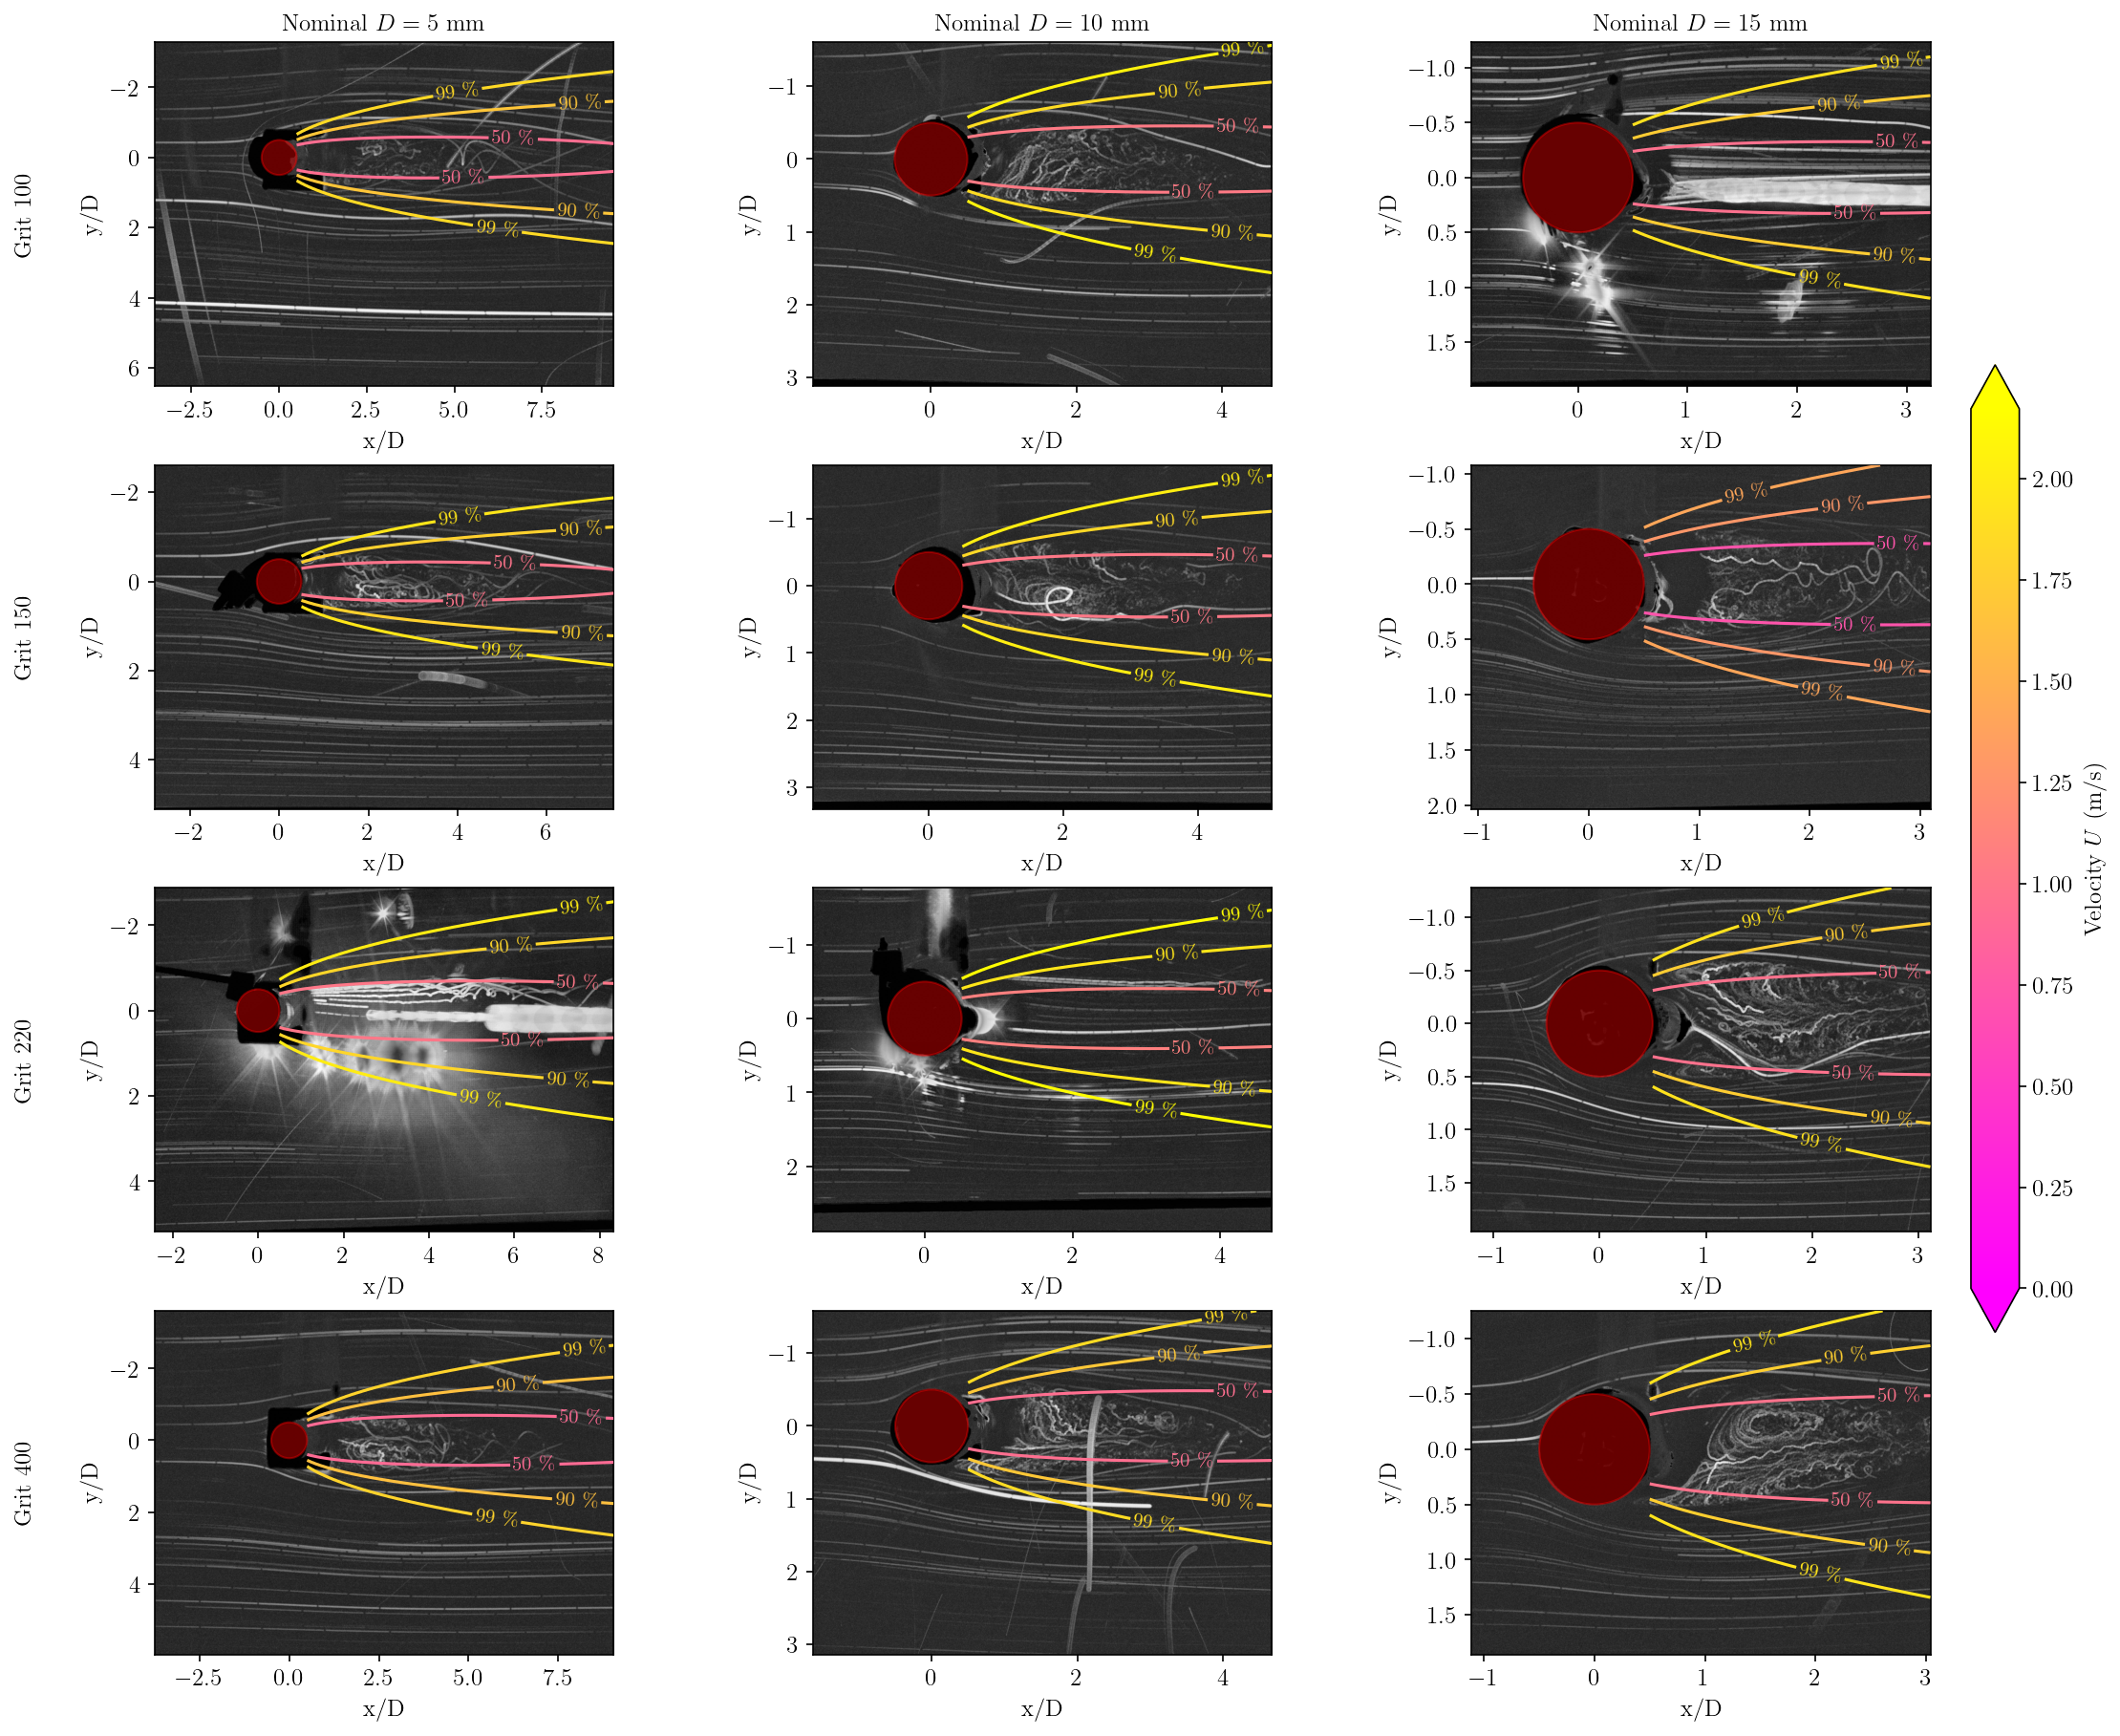

In [9]:
def plot_wake_grid(tests: list, scatter=False, figsize=(15, 12)):
    test_map = {(t.grit, t.nominal_diameter_mm): t for t in tests}
    grits     = sorted(set(t.grit for t in tests))
    diameters = sorted(set(t.nominal_diameter_mm for t in tests))
    n_row, n_col = len(grits), len(diameters)

    all_v = pd.concat([t.measurements_df["V"] for t in tests], ignore_index=True)
    # shared_norm = colors.Normalize(vmin=all_v.min(), vmax=all_v.max())
    shared_norm = colors.Normalize(vmin=0.0, vmax=df["U_inf"].max(), clip=True)
    shared_cmap = cm.spring

    fig, axes = plt.subplots(n_row, n_col, figsize=figsize, constrained_layout=True)

    for col, diam in enumerate(diameters):
        axes[0, col].set_title(f"Nominal $D = {diam}$ mm", fontsize=12, fontweight="bold")
    for row, grit in enumerate(grits):
        axes[row, 0].annotate(
            f"Grit {grit}",
            xy=(0, 0.5), xycoords="axes fraction",
            xytext=(-60, 0), textcoords="offset points",
            ha="right", va="center",
            fontsize=12, fontweight="bold", rotation=90,
        )

    for row, grit in enumerate(grits):
        for col, diam in enumerate(diameters):
            ax = axes[row, col]
            test = test_map.get((grit, diam))

            if test is None:
                ax.set_visible(False)
                continue

            test.show_wake(ax=ax, norm=shared_norm, cmap=shared_cmap, scatter=scatter)

    mappable = cm.ScalarMappable(norm=shared_norm, cmap=shared_cmap)
    mappable.set_array([])

    fig.colorbar(
        mappable,
        ax=axes.ravel().tolist(), # attaches to the whole grid
        label="Velocity $U$ (m/s)",
        extend="both",
        shrink=0.6,
        pad=0.02,
    )
    # plt.subplots_adjust(hspace=0.2)
    # fig.tight_layout()

    fig.savefig(fig_path / "wake_grid.png")

    return fig, axes

plot_wake_grid(tests)
pass

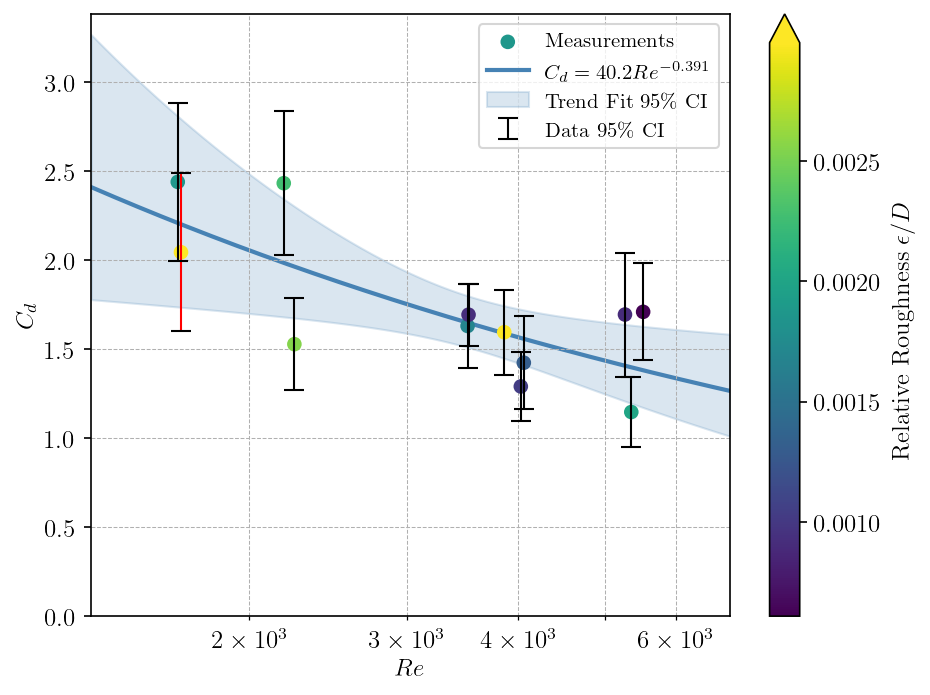

In [10]:
# weighted log-space trendline
# propagate uncertainty through log10 transform
log_Re  = np.log10(df["Re"])
log_Cd  = np.log10(df["C_d"])
sigma_log_Cd = df["C_d_std"] / (df["C_d"] * np.log(10))

weights = 1.0 / sigma_log_Cd**2 # inverse-variance weights

# weighted linear fit
coeffs, cov = np.polyfit(log_Re, log_Cd, deg=1, w=weights, cov=True)

Re_lim = (0.8 * df["Re"].min(), 1.25 * df["Re"].max())
Re_fit     = np.logspace(np.log10(Re_lim[0]), np.log10(Re_lim[1]), 300)
log_Re_fit = np.log10(Re_fit)

log_Cd_fit = np.polyval(coeffs, log_Re_fit)

# CI of the fit line
X_fit    = np.column_stack([log_Re_fit, np.ones_like(log_Re_fit)]) # (N, 2)
var_fit = (X_fit @ cov * X_fit).sum(axis=1)
t_crit   = t.ppf(0.975, df=len(df) - 2)
half_ci  = t_crit * np.sqrt(var_fit)

Cd_fit   = 10**log_Cd_fit
Cd_upper = 10**(log_Cd_fit + half_ci)
Cd_lower = 10**(log_Cd_fit - half_ci)

b, log_a = coeffs
label_fit = rf"$C_d = {10**log_a:.3g} Re^{{{b:.3f}}}$"

roughness_norm = colors.Normalize(
    vmin=df["rel_roughness"].min(),
    vmax=df[~df["Outlier"]]["rel_roughness"].max(),
)
cmap = cm.viridis

fig, ax = plt.subplots()

sc = ax.scatter(
    df["Re"], df["C_d"],
    c=df["rel_roughness"], cmap=cmap, norm=roughness_norm,
    zorder=3,
    label="Measurements"
)

errorbars = ax.errorbar(
    df["Re"], df["C_d"],
    yerr=df["C_d_CI"],
    fmt="none", ecolor="black", elinewidth=1, capsize=5, zorder=4,
    label="Data 95\% CI"
)
errorbars.lines[2][0].set_colors(
    ["red" if outlier else "black" for outlier in df["Outlier"]]
)

ax.plot(Re_fit, Cd_fit, color="steelblue", lw=2, label=label_fit, zorder=0)
ax.fill_between(
    Re_fit, Cd_lower, Cd_upper,
    color="steelblue", alpha=0.20, label="Trend Fit 95\% CI"
)

fig.colorbar(sc, ax=ax, extend="max", label=r"Relative Roughness $\epsilon / D$")
ax.set_xscale("log")
ax.grid(which="both", ls="--", lw=0.5)
ax.set_xlim(Re_lim)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("$Re$")
ax.set_ylabel("$C_d$")
ax.legend()
plt.tight_layout()

fig.savefig(fig_path / "Cd_Re.png")

c:\Users\rohan\OneDrive\Documents\_Current_Semester\ME_30801\Labs\Open_Lab\testing.py:670: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 100, using nperseg = 100
  xf, power = welch(signal, self.frame_rate, window="hann", axis=0) # psd
c:\Users\rohan\OneDrive\Documents\_Current_Semester\ME_30801\Labs\Open_Lab\testing.py:670: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 50, using nperseg = 50
  xf, power = welch(signal, self.frame_rate, window="hann", axis=0) # psd


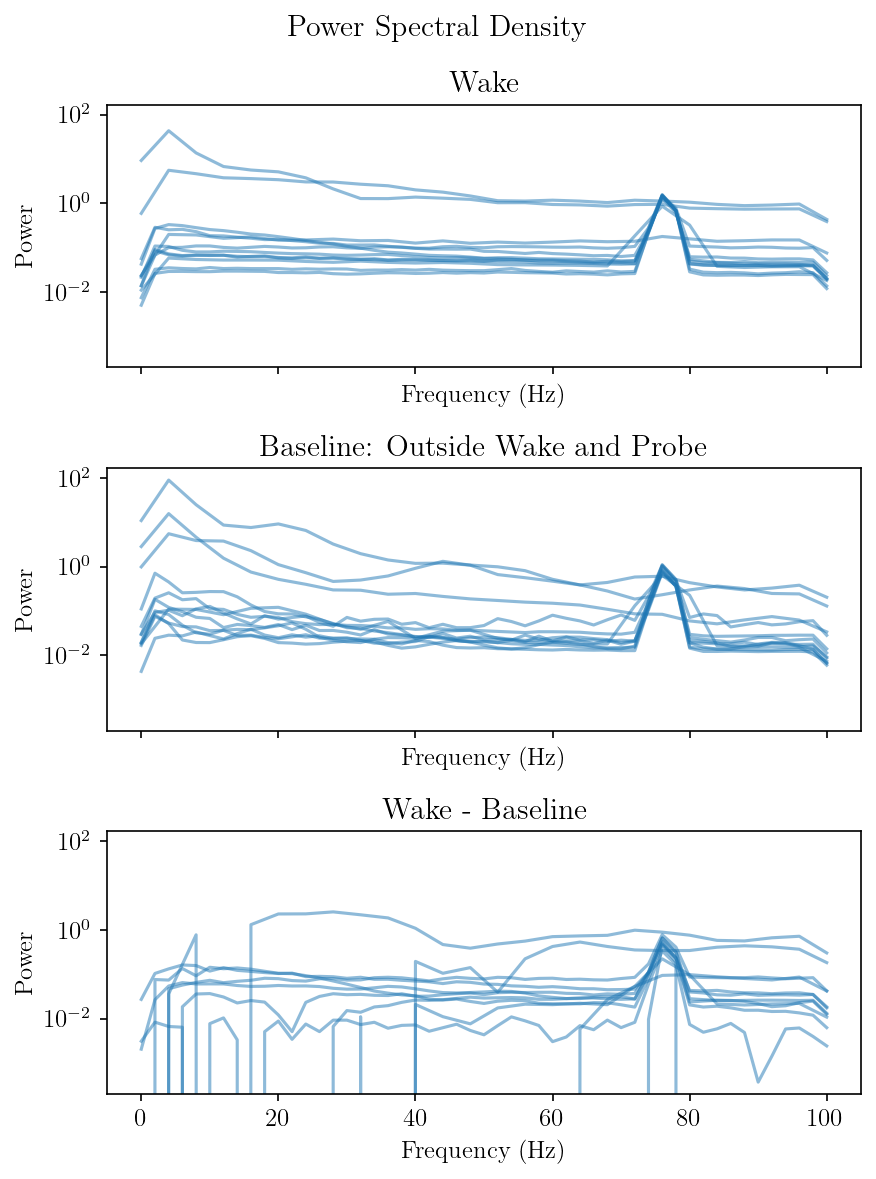

In [11]:
fig, axes = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(6, 8))
titles = ["Wake", "Baseline: Outside Wake and Probe", "Wake - Baseline"]

for test in tests:
    power_data = test.freq_analysis() # (wake, baseline, difference)

    for ax, power in zip(axes, power_data):
        ax.plot(test.xf, power, color="C0", alpha=0.5)

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.set_yscale("log")

fig.suptitle("Power Spectral Density")
plt.tight_layout()

fig.savefig(fig_path / "psd_comparison.png")

In [12]:
df_St = df[["D_nominal_mm", "grit", "Re", "St", "rank"]]
print("Highest rank used (after filtering):", df_St.explode("rank")["rank"].max())

Highest rank used (after filtering): 11


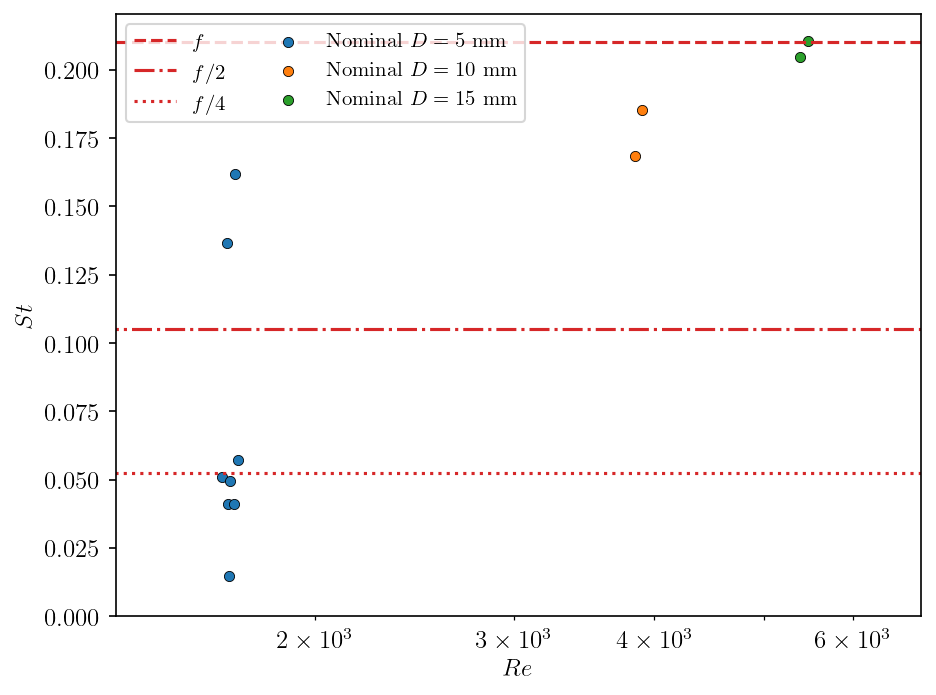

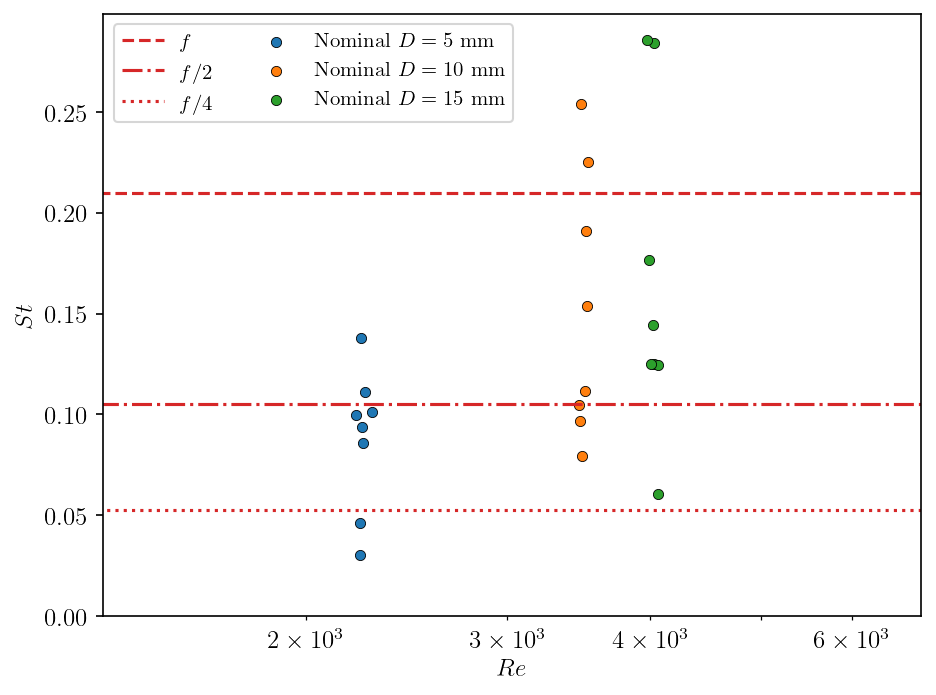

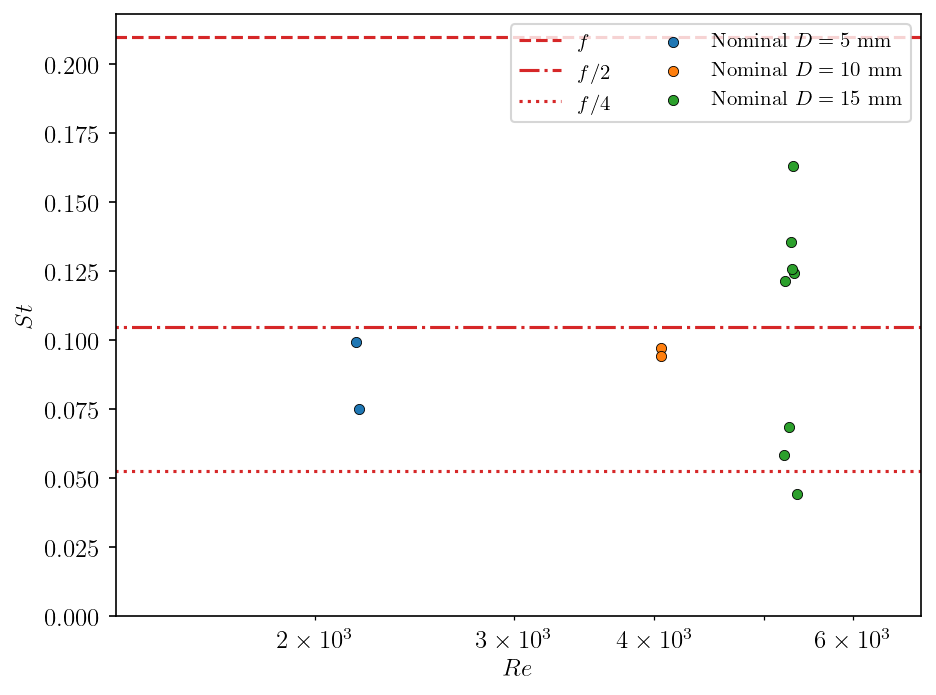

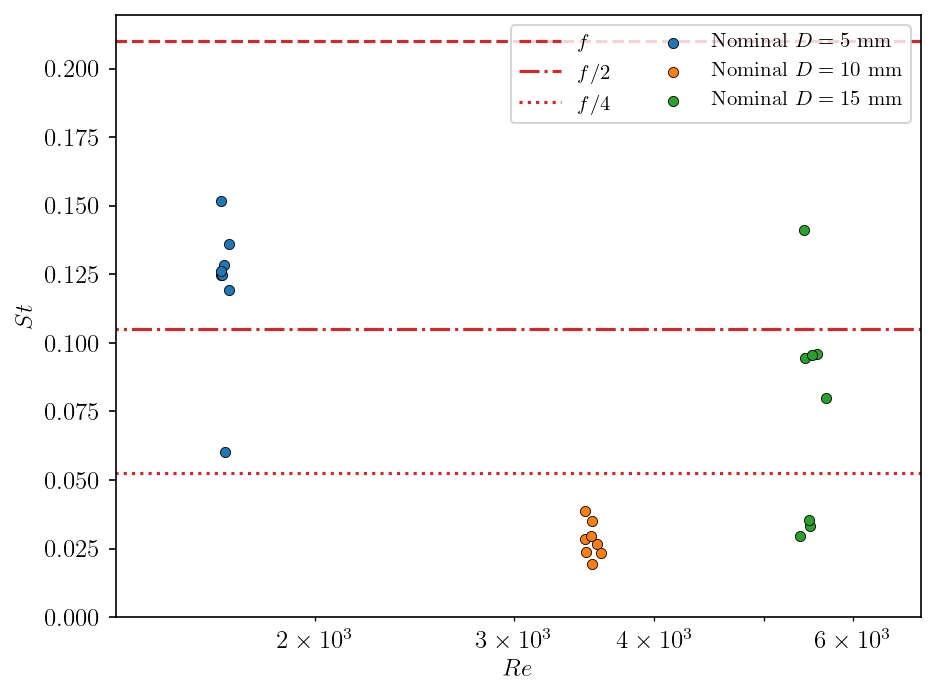

In [13]:
for grit, cur_df in df_St.groupby("grit"):
    fig, ax = plt.subplots()
    ax.hlines(0.21 / 1, 4e2, 1e4, ls="--", color="C3", label="$f$")
    ax.hlines(0.21 / 2, 4e2, 1e4, ls="-.", color="C3", label="$f/2$")
    ax.hlines(0.21 / 4, 4e2, 1e4, ls=":", color="C3", label="$f/4$")

    for i, row in cur_df.iterrows():
        # sc = ax.scatter([row["Re"]] * len(row["St"]), row["St"], c=row["rank"], cmap="viridis")
        # sc = ax.scatter([row["Re"]] * len(row["St"]), row["St"], label=f"Nominal $D = {row['D_nominal_mm']}$ mm")
        x_jitter = row["Re"] * (1 + 0.01 * np.random.randn(len(row["St"])))
        sc = ax.scatter(x_jitter, row["St"], label=f"Nominal $D = {row['D_nominal_mm']}$ mm", s=24, edgecolors="black", lw=0.4)
    
    # fig.colorbar(sc)

    ax.set_xscale("log")
    # ax.grid("both")
    ax.set_xlim(Re_lim)
    ax.set_ylim(bottom=0)

    ax.set_xlabel("$Re$")
    ax.set_ylabel("$St$")
    # ax.set_title(f"{grit = }")
    ax.legend(ncol=2, loc="best")
    fig.tight_layout()
    fig.savefig(fig_path / f"grit_{grit}_St_Re")

In [14]:
# ! jupyter nbconvert --to script analysis.ipynb